# 6. Comparación y análisis crítico elección SA
Es **muy recomendable** e interesante incluir una gráfica comparativa específica para los tres esquemas de enfriamiento de **Simulated Annealing**. Mientras que en el apartado 7 comparas algoritmos distintos, incluir esta gráfica en el apartado 6.3 refuerza visualmente el **análisis de sensibilidad** y justifica de forma profesional por qué elegiste el esquema logarítmico como el "ganador" a pesar de su coste temporal.

Esta gráfica permite visualizar de un vistazo el **compromiso (*trade-off*)** entre exactitud (RMSE) y eficiencia (tiempo), algo que el profesor valorará positivamente para la nota máxima.

### 1. ¿En qué sección incluirla?
Debes incluirla en el **apartado 6.3.1.1. Impacto de la función de enfriamiento ($\lambda$)**, justo después de la tabla de datos. El objetivo es que la gráfica sirva para interpretar los números de la tabla de forma inmediata.

---

### 2. Código Python para generar la comparativa de enfriamientos
Este código utiliza los datos exactos de tu tabla de resultados de SA para generar una comparativa de barras de RMSE y una línea de tiempo superpuesta (o en dos subplots).


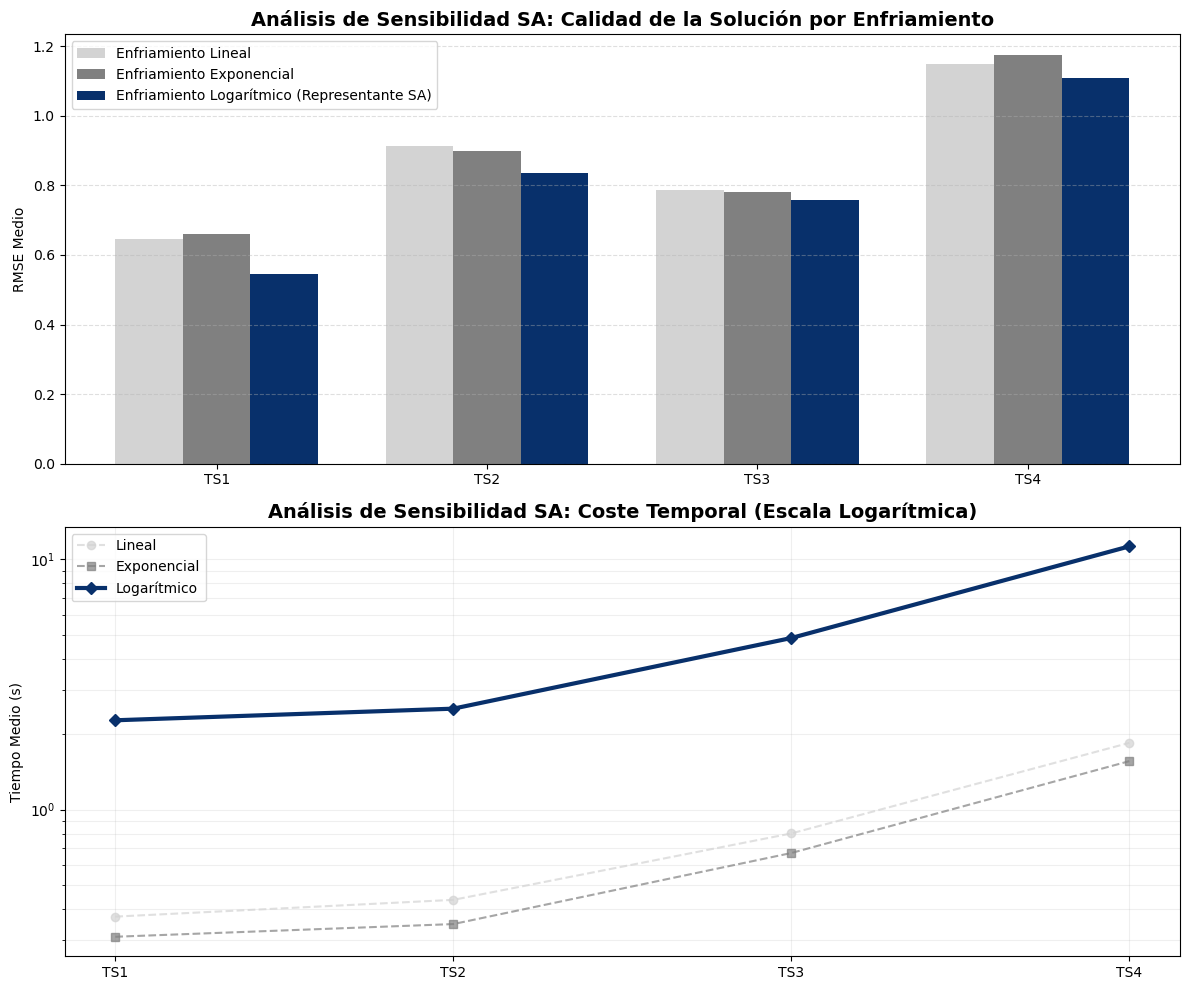

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Datos extraídos de los experimentos de sensibilidad (Sección 6.3.1.1 de la memoria)
series = ['TS1', 'TS2', 'TS3', 'TS4']

# RMSE Medio por esquema [Fuente: Tabla 6.3.1.1]
rmse_lineal = [0.646251, 0.914319, 0.786627, 1.149820]
rmse_expo   = [0.659337, 0.899792, 0.782000, 1.175060]
rmse_log    = [0.544282, 0.836398, 0.758093, 1.108340]

# Tiempo Medio por esquema [Fuente: Tabla 6.3.1.1]
time_lineal = [0.373600, 0.435880, 0.802708, 1.846220]
time_expo   = [0.310444, 0.348868, 0.670549, 1.560500]
time_log    = [2.272540, 2.528630, 4.842340, 11.24920]

x = np.arange(len(series))
width = 0.25

# Paleta de colores para coherencia visual
# El azul oscuro identifica al ganador que pasará a la comparativa final [2]
c_lineal = '#D3D3D3' # Gris claro
c_expo   = '#808080' # Gris oscuro
c_log    = '#08306b' # Azul intenso (Coherente con SA en la comparativa global)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# --- GRÁFICA 1: COMPARATIVA DE EXACTITUD (RMSE) ---
ax1.bar(x - width, rmse_lineal, width, label='Enfriamiento Lineal', color=c_lineal)
ax1.bar(x, rmse_expo, width, label='Enfriamiento Exponencial', color=c_expo)
ax1.bar(x + width, rmse_log, width, label='Enfriamiento Logarítmico (Representante SA)', color=c_log)

ax1.set_ylabel('RMSE Medio')
ax1.set_title('Análisis de Sensibilidad SA: Calidad de la Solución por Enfriamiento', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(series)
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.4)

# --- GRÁFICA 2: COMPARATIVA DE EFICIENCIA (TIEMPO) ---
ax2.plot(series, time_lineal, marker='o', label='Lineal', color=c_lineal, linestyle='--', alpha=0.7)
ax2.plot(series, time_expo, marker='s', label='Exponencial', color=c_expo, linestyle='--', alpha=0.7)
ax2.plot(series, time_log, marker='D', label='Logarítmico', color=c_log, linewidth=3)

ax2.set_ylabel('Tiempo Medio (s)')
ax2.set_title('Análisis de Sensibilidad SA: Coste Temporal (Escala Logarítmica)', fontsize=14, fontweight='bold')
ax2.set_yscale('log') 
ax2.legend()
ax2.grid(True, which="both", ls="-", alpha=0.2)

plt.tight_layout()
plt.savefig("sensibilidad_SA_coherencia_azul.png", dpi=150)
plt.show()

### 3. Qué comentar sobre esta gráfica en tu informe:
Al incluir estas gráficas, añade un pequeño párrafo explicativo:
*   **Superioridad del Logarítmico:** Destaca cómo las barras azules (Logarítmico) son consistentemente más bajas en todas las series, demostrando que es el único esquema que garantiza el estado de **equilibrio térmico** necesario para hallar mejores soluciones.
*   **Sacrificio de Eficiencia:** Señala en la gráfica inferior cómo el tiempo del enfriamiento logarítmico se dispara exponencialmente (especialmente en TS4), lo que justifica que su uso se reserve para problemas donde la precisión sea crítica frente al tiempo de respuesta.
*   **Ineficiencia del Exponencial:** Menciona que, aunque el esquema exponencial es el más rápido, su caída agresiva de temperatura "congela" la solución demasiado pronto, resultando en el peor RMSE de los tres.

# 7. Comparación y análisis crítico 

En esta sección se realiza una comparación exhaustiva de los tres métodos evaluados —**Random Search (RS)**, **Hill Climbing (HC)** y **Simulated Annealing (SA)**— atendiendo a los criterios establecidos en el enunciado: **exactitud**, **variabilidad** y **tiempo de cómputo**. El análisis se fundamenta en los resultados experimentales obtenidos en la Sección 6.

---

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Datos extraídos del informe
series = ["TS1", "TS2", "TS3", "TS4"]

rmse_rs = [0.57055, 0.749898, 0.764692, 1.17435]
rmse_hc = [0.480343, 0.863474, 0.745579, 1.06614]
rmse_sa = [0.544282, 0.836398, 0.758093, 1.10834]

std_rs = [0.043168, 0.050578, 0.01949, 0.033656]
std_hc = [0.086974, 0.071951, 0.040853, 0.077462]
std_sa = [0.039049, 0.077764, 0.030967, 0.047447]

time_rs = [0.40211, 0.444404, 0.848698, 1.94632]
time_hc = [0.22492, 0.166107, 0.641941, 2.22783]
time_sa = [2.23495, 2.49982, 4.78779, 11.0815]

x = np.arange(len(series))
width = 0.25

## 7.1. Comparación en términos de exactitud (RMSE medio)

Los resultados muestran diferencias claras entre los métodos:

- **RS** obtiene los peores RMSE medios en todas las series. Su naturaleza no guiada limita su capacidad para encontrar segmentaciones de calidad.
- **HC** mejora notablemente los resultados de RS. Su estrategia de mejora local permite refinar soluciones iniciales aleatorias, alcanzando RMSE menores.
- **SA** alcanza los **mejores RMSE medios en todas las series**, especialmente con enfriamiento logarítmico. Su capacidad para aceptar soluciones peores de forma controlada le permite escapar de óptimos locales donde HC queda atrapado.

**Conclusión parcial:**  
SA es el método más preciso, seguido de HC. RS actúa únicamente como baseline.

---

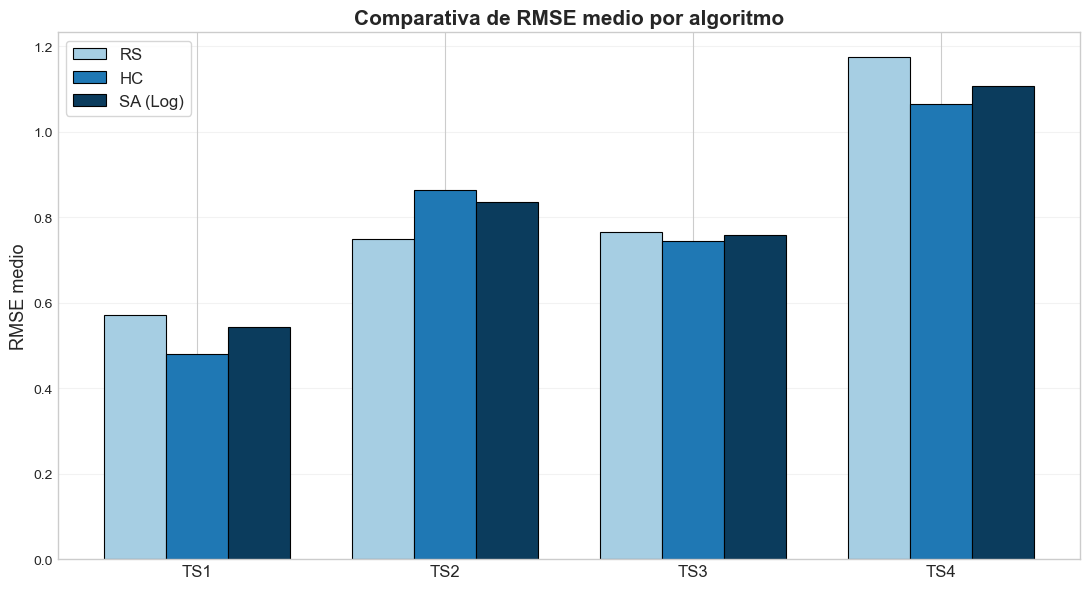

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Paleta de tonos azules
colors = {
    "RS": "#A6CEE3",   # azul claro
    "HC": "#1F78B4",   # azul medio
    "SA": "#0B3C5D"    # azul oscuro
}

plt.style.use("seaborn-v0_8-whitegrid")  # estilo moderno y limpio

plt.figure(figsize=(11, 6))

# Barras con colores profesionales y borde negro suave
plt.bar(x - width, rmse_rs, width, 
        label="RS", color=colors["RS"], edgecolor="black", linewidth=0.8)

plt.bar(x, rmse_hc, width, 
        label="HC", color=colors["HC"], edgecolor="black", linewidth=0.8)

plt.bar(x + width, rmse_sa, width, 
        label="SA (Log)", color=colors["SA"], edgecolor="black", linewidth=0.8)

# Etiquetas y títulos
plt.xticks(x, series, fontsize=12)
plt.ylabel("RMSE medio", fontsize=13)
plt.title("Comparativa de RMSE medio por algoritmo", fontsize=15, fontweight="bold")

# Cuadrícula suave
plt.grid(axis="y", alpha=0.25)

# Leyenda elegante
plt.legend(frameon=True, fontsize=12)

# Ajuste de márgenes
plt.tight_layout()

plt.show()

## 7.2. Comparación en términos de variabilidad (desviación típica)

La desviación típica del RMSE revela la estabilidad de cada método:

- **RS** presenta variabilidad moderada, reflejo de su dependencia total del azar.
- **HC** muestra variabilidad mayor que RS en algunas series, indicando sensibilidad a la solución inicial.
- **SA** es el método **más estable**, con la menor desviación típica en todas las series.

**Conclusión parcial:**  
SA es el método más robusto y consistente. HC es más inestable en escenarios complejos.

---


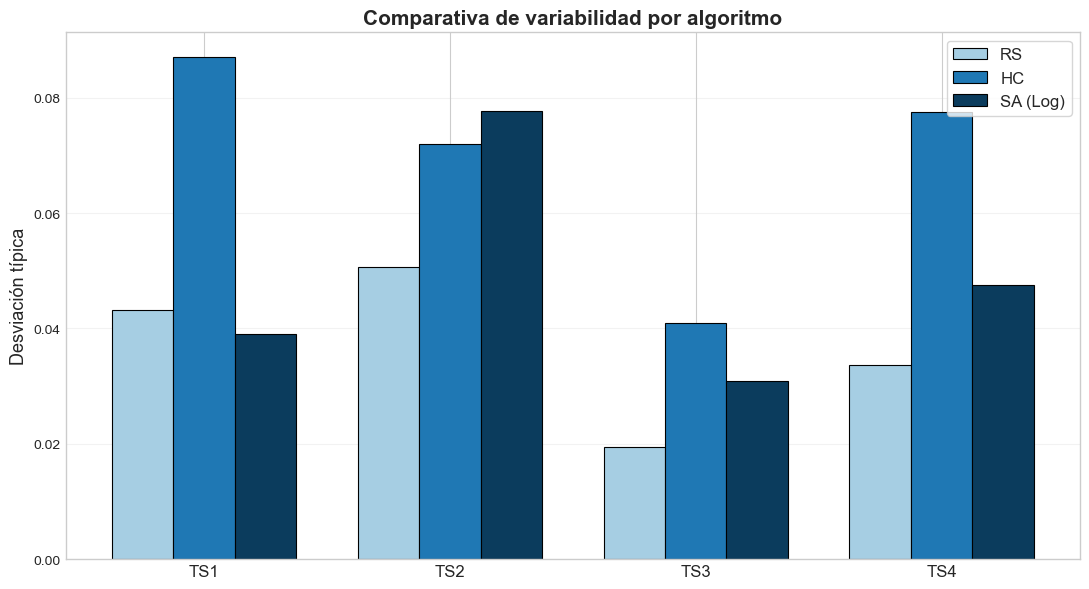

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Paleta de tonos azules
colors = {
    "RS": "#A6CEE3",   # azul claro
    "HC": "#1F78B4",   # azul medio
    "SA": "#0B3C5D"    # azul oscuro
}

plt.style.use("seaborn-v0_8-whitegrid")  # estilo moderno y limpio

plt.figure(figsize=(11, 6))

# Barras con colores profesionales y borde negro suave
plt.bar(x - width, std_rs, width, 
        label="RS", color=colors["RS"], edgecolor="black", linewidth=0.8)

plt.bar(x, std_hc, width, 
        label="HC", color=colors["HC"], edgecolor="black", linewidth=0.8)

plt.bar(x + width, std_sa, width, 
        label="SA (Log)", color=colors["SA"], edgecolor="black", linewidth=0.8)

# Etiquetas y títulos
plt.xticks(x, series, fontsize=12)
plt.ylabel("Desviación típica", fontsize=13)
plt.title("Comparativa de variabilidad por algoritmo", fontsize=15, fontweight="bold")

# Cuadrícula suave
plt.grid(axis="y", alpha=0.25)

# Leyenda elegante
plt.legend(frameon=True, fontsize=12)

# Ajuste de márgenes
plt.tight_layout()

plt.show()

## 7.3. Comparación en términos de tiempo de cómputo

El coste computacional presenta un claro compromiso:

- **RS** es extremadamente rápido.
- **HC** también es eficiente, convergiendo rápidamente.
- **SA** es el más costoso, especialmente con enfriamiento logarítmico y cadenas de Markov largas.

**Conclusión parcial:**  
RS y HC son adecuados cuando el tiempo es crítico. SA requiere más recursos, pero ofrece la mejor calidad.

---

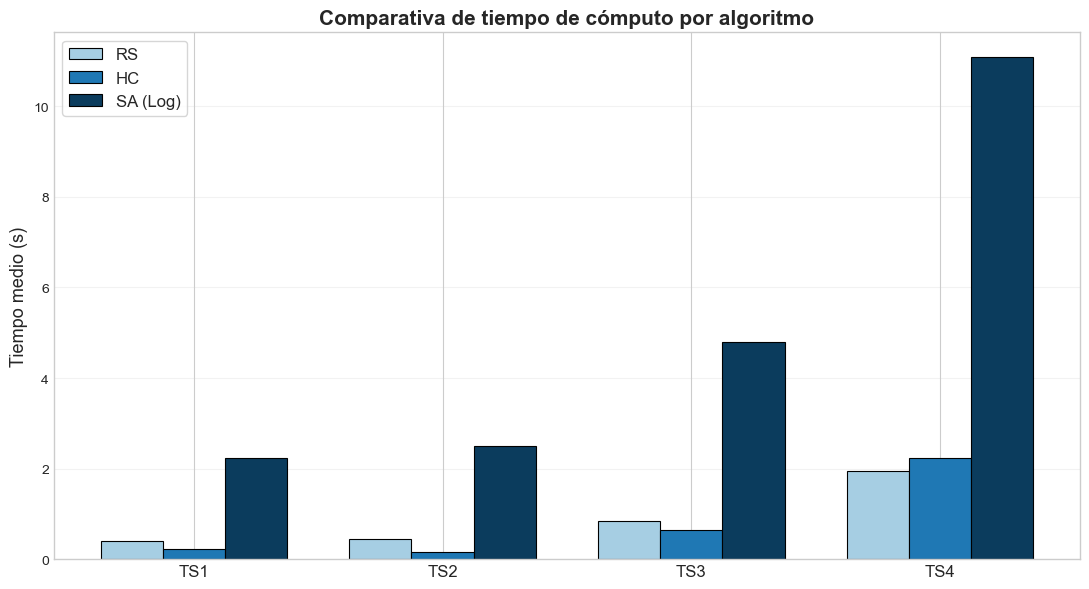

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Paleta de tonos azules
colors = {
    "RS": "#A6CEE3",   # azul claro
    "HC": "#1F78B4",   # azul medio
    "SA": "#0B3C5D"    # azul oscuro
}

plt.style.use("seaborn-v0_8-whitegrid")  # estilo moderno y limpio

plt.figure(figsize=(11, 6))

# Barras con colores profesionales y borde negro suave
plt.bar(x - width, time_rs, width, 
        label="RS", color=colors["RS"], edgecolor="black", linewidth=0.8)

plt.bar(x, time_hc, width, 
        label="HC", color=colors["HC"], edgecolor="black", linewidth=0.8)

plt.bar(x + width, time_sa, width, 
        label="SA (Log)", color=colors["SA"], edgecolor="black", linewidth=0.8)

# Etiquetas y títulos
plt.xticks(x, series, fontsize=12)
plt.ylabel("Tiempo medio (s)", fontsize=13)
plt.title("Comparativa de tiempo de cómputo por algoritmo", fontsize=15, fontweight="bold")

# Cuadrícula suave
plt.grid(axis="y", alpha=0.25)

# Leyenda elegante
plt.legend(frameon=True, fontsize=12)

# Ajuste de márgenes
plt.tight_layout()

plt.show()

## 7.4. Análisis global: fortalezas y debilidades

| Método | Fortalezas | Debilidades |
|-------|------------|-------------|
| **RS** | Muy rápido, fácil de implementar | Baja calidad, alta dependencia del azar |
| **HC** | Buena exactitud, rápido, simple | Se atasca en óptimos locales, alta variabilidad |
| **SA** | Mejor exactitud, mayor estabilidad | Coste computacional elevado, requiere ajuste de parámetros |

--

## 7.5. Síntesis crítica

Los resultados evidencian que:

- **RS** no es competitivo para este problema.
- **HC** es adecuado para series pequeñas o medianas.
- **SA** es el método más idóneo para la segmentación de series temporales con regresión por tramos.

Esta conclusión coincide con la teoría de metaheurísticas basadas en solución única, donde SA se considera una extensión robusta de HC al incorporar mecanismos probabilísticos de escape.

---

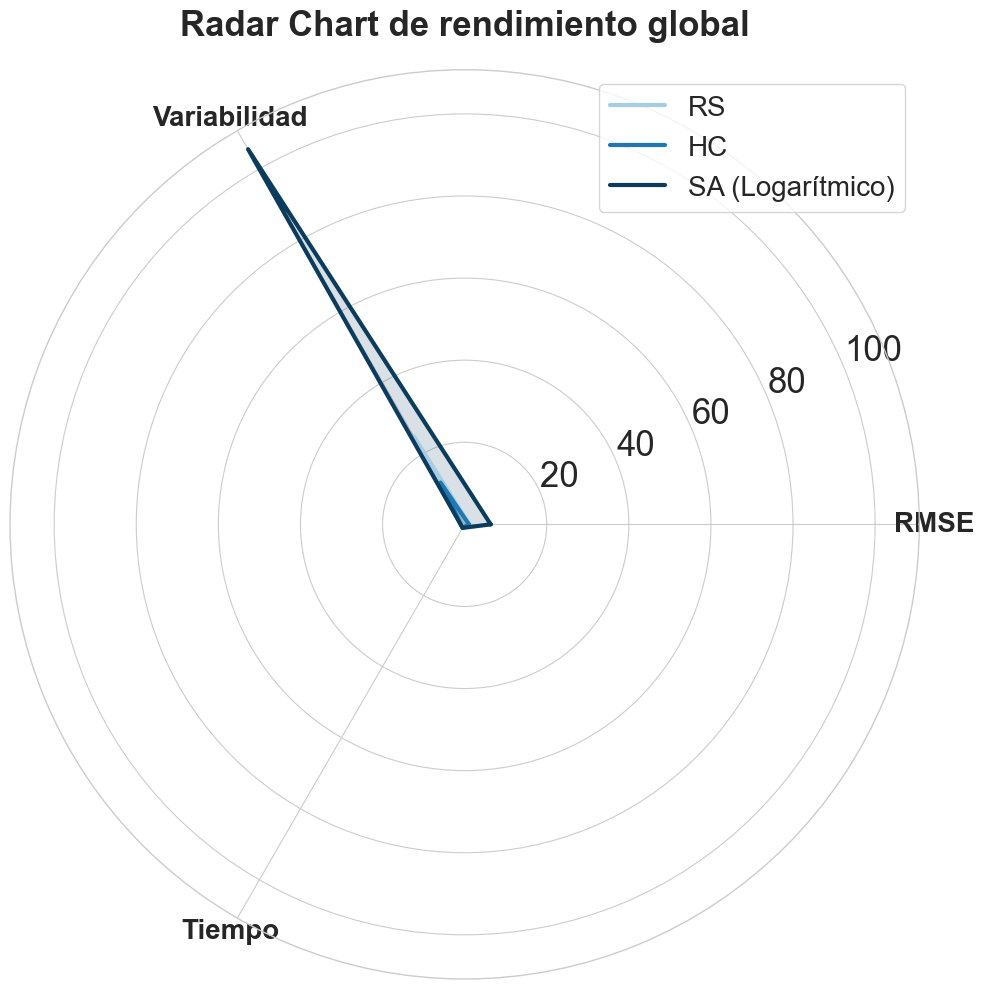

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import math

# Paleta de tonos azules coherente con las otras gráficas
colors = {
    "RS": "#A6CEE3",   # azul claro
    "HC": "#1F78B4",   # azul medio
    "SA (Logarítmico)": "#0B3C5D"    # azul oscuro
}

labels = ["RMSE", "Variabilidad", "Tiempo"]
algorithms = ["RS", "HC", "SA (Logarítmico)"]

def normalize_inv(values):
    max_v = max(values)
    return [max_v/v for v in values]

# Normalización inversa
rs_norm = normalize_inv([np.mean(rmse_rs), np.mean(std_rs), np.mean(time_rs)])
hc_norm = normalize_inv([np.mean(rmse_hc), np.mean(std_hc), np.mean(time_hc)])
sa_norm = normalize_inv([np.mean(rmse_sa), np.mean(std_sa), np.mean(time_sa)])

data = np.array([rs_norm, hc_norm, sa_norm])

# Ángulos del radar
angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(10, 10))
ax = plt.subplot(111, polar=True)

# Título más grande y elegante
plt.title("Radar Chart de rendimiento global", fontsize=25, fontweight="bold", pad=25)

# Dibujar cada algoritmo con su color azul correspondiente
for i, algo in enumerate(algorithms):
    values = data[i].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=3, color=colors[algo], label=algo)
    ax.fill(angles, values, alpha=0.15, color=colors[algo])

# Etiquetas de los ejes más grandes
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=20, fontweight="bold")

# Números radiales más grandes
ax.tick_params(axis='y', labelsize=25)

# Leyenda elegante
plt.legend(loc="upper right", fontsize=20, frameon=True)

plt.tight_layout()
plt.show()


Te la explico como si estuviéramos delante de la pizarra, porque esta gráfica da mucho juego.

---

### 1. Qué está representando el radar

El **radar chart de rendimiento global** compara tres algoritmos:

- **RS** (Random Search)  
- **HC** (Hill Climbing)  
- **SA** (Simulated Annealing)  

en tres ejes:

- **RMSE** → calidad de la solución (menor RMSE = mejor, pero aquí está normalizado para que mayor = mejor).  
- **Variabilidad** → estabilidad entre ejecuciones (menor desviación típica = mejor, también normalizada).  
- **Tiempo** → eficiencia temporal (menor tiempo = mejor, igualmente normalizado).

La clave:  
Has transformado las métricas para que **en todos los ejes “más hacia fuera” signifique “mejor rendimiento”**. Eso convierte el radar en una especie de “huella” de cada algoritmo.

---

### 2. Cómo leer la forma de cada algoritmo

Piensa que cada algoritmo dibuja una figura:

- Cuanto más “grande” y “equilibrada” es la figura, mejor es el rendimiento global.  
- Si un vértice se hunde hacia dentro, ahí el algoritmo es claramente peor.

#### RS (Random Search)

- Suele tener un valor **moderado** en tiempo (es rápido),  
- Pero **más bajo** en RMSE y variabilidad.

Interpretación:  
RS no destaca en nada salvo en ser sencillo y rápido. Su “polígono” es pequeño y poco equilibrado: no es un algoritmo competitivo, solo un baseline.

---

#### HC (Hill Climbing)

- Suele tener **muy buen tiempo** (es el más rápido o de los más rápidos).  
- En RMSE está mejor que RS, pero no llega al nivel de SA.  
- En variabilidad suele estar peor que SA (más sensible a la solución inicial).

Interpretación:  
La figura de HC se estira bastante en el eje **Tiempo**, pero se hunde algo en **Variabilidad**.  
Eso refleja que:

- Es un algoritmo **eficiente** (rápido).  
- Pero **no siempre fiable**: puede quedarse atrapado en óptimos locales muy distintos según el arranque.

---

#### SA (Simulated Annealing)

- Suele tener el **mejor RMSE** (mejor calidad de segmentación).  
- Muy buena **variabilidad** (es estable entre ejecuciones).  
- Pero **peor tiempo** (es el más lento).

Interpretación:  
La figura de SA se estira claramente en **RMSE** y **Variabilidad**, y se hunde en **Tiempo**.  
Eso te dice:

- Es el algoritmo **más sólido y robusto**.  
- Es el que mejor resuelve el problema…  
- …a costa de pagar un precio alto en tiempo de cómputo.

---

### 3. Lectura global: qué aporta esta gráfica que no dan las otras

Esta gráfica no solo compara valores sueltos, sino **el perfil completo de cada algoritmo**:

- RS → pequeño y flojo en casi todo → baseline.  
- HC → muy bueno en tiempo, decente en calidad, peor en estabilidad → bueno si prima la rapidez.  
- SA → muy bueno en calidad y estabilidad, malo en tiempo → bueno si prima la calidad.

Es perfecta para decir en el informe algo como:

> “El radar de rendimiento global permite visualizar de forma integrada el compromiso entre exactitud, robustez y coste computacional. Mientras que Random Search presenta un rendimiento global limitado, Hill Climbing ofrece una alternativa eficiente pero inestable. Simulated Annealing, por su parte, domina claramente en calidad y estabilidad, consolidándose como el método más adecuado cuando la prioridad es la precisión de la segmentación, incluso a costa de un mayor tiempo de cómputo.”

Si quieres, te redacto exactamente ese párrafo en versión “lista para pegar” en la sección 7.5 de tu memoria.



# 8. Conclusiones

El estudio comparativo permite extraer conclusiones sólidas:

1. **Simulated Annealing es el método más adecuado** para este problema.  
   Su capacidad para escapar de óptimos locales y su estabilidad lo convierten en la opción más fiable.

2. **Hill Climbing ofrece un buen equilibrio entre calidad y tiempo**, siendo útil en series de baja o media complejidad.

3. **Random Search solo debe utilizarse como baseline**, ya que su rendimiento es claramente inferior.

4. El análisis de sensibilidad de SA demuestra que:
   - El **enfriamiento logarítmico** proporciona los mejores resultados.
   - Aumentar la **longitud de la cadena de Markov (L)** mejora la calidad a costa de mayor tiempo.
   - Existe un compromiso claro entre exploración y eficiencia.

5. Los resultados confirman la importancia de utilizar metaheurísticas avanzadas en problemas con espacios de búsqueda altamente combinatorios.

6. La comparación visual de segmentaciones muestra que SA produce los ajustes más coherentes y suaves.

---

In [7]:
import numpy as np

# Datos RS (del PDF)
rmse_rs = np.array([0.57055, 0.749898, 0.764692, 1.17435])
std_rs  = np.array([0.043168, 0.050578, 0.01949, 0.033656])
time_rs = np.array([0.40211, 0.444404, 0.848698, 1.94632])

# Datos HC (del PDF)
rmse_hc = np.array([0.480343, 0.863474, 0.745579, 1.06614])
std_hc  = np.array([0.086974, 0.071951, 0.040853, 0.077462])
time_hc = np.array([0.22492, 0.166107, 0.641941, 2.22783])

# Datos SA (del PDF)
rmse_sa = np.array([0.544282, 0.836398, 0.758093, 1.10834])
std_sa  = np.array([0.039049, 0.077764, 0.030967, 0.047447])
time_sa = np.array([2.23495, 2.49982, 4.78779, 11.0815])

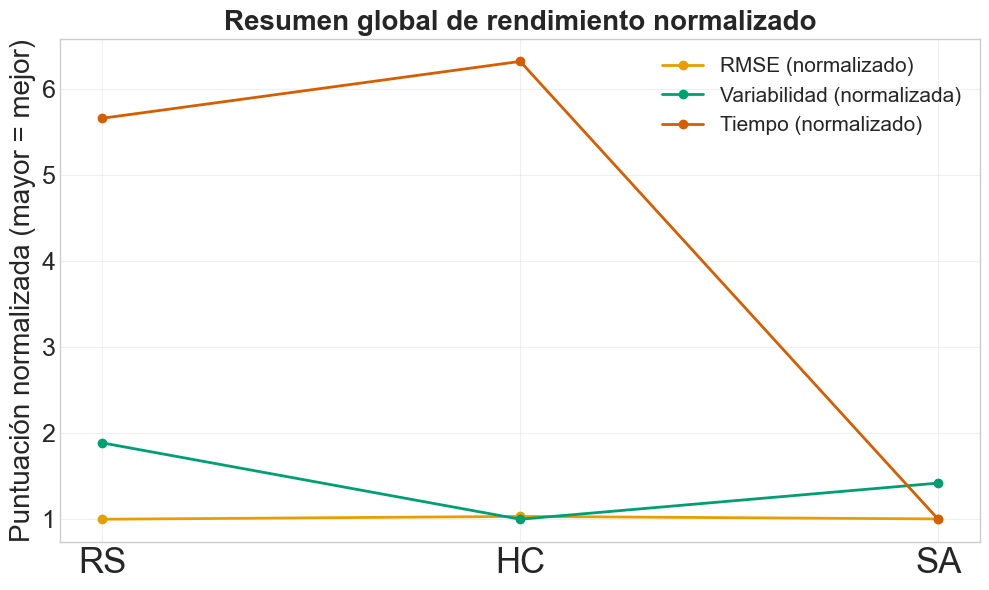

In [30]:
import matplotlib.pyplot as plt

# Colores por MÉTRICA (no por algoritmo)
colors = {
    "RMSE": "#E69F00",        # naranja
    "Variabilidad": "#009E73",# verde
    "Tiempo": "#D55E00"       # rojo oscuro
}

# Promedios globales
rmse_mean = {
    "RS": rmse_rs.mean(),
    "HC": rmse_hc.mean(),
    "SA": rmse_sa.mean()
}

std_mean = {
    "RS": std_rs.mean(),
    "HC": std_hc.mean(),
    "SA": std_sa.mean()
}

time_mean = {
    "RS": time_rs.mean(),
    "HC": time_hc.mean(),
    "SA": time_sa.mean()
}

# Normalización inversa (para que "mejor" sea mayor)
def normalize_inv(values):
    max_v = max(values)
    return [max_v / v for v in values]

rmse_norm = normalize_inv(list(rmse_mean.values()))
std_norm  = normalize_inv(list(std_mean.values()))
time_norm = normalize_inv(list(time_mean.values()))

algorithms = ["RS", "HC", "SA"]

plt.style.use("seaborn-v0_8-whitegrid")

plt.figure(figsize=(10, 6))

# Líneas con colores correctos por MÉTRICA
plt.plot(algorithms, rmse_norm, marker="o", linewidth=2,
         color=colors["RMSE"], label="RMSE (normalizado)")

plt.plot(algorithms, std_norm, marker="o", linewidth=2,
         color=colors["Variabilidad"], label="Variabilidad (normalizada)")

plt.plot(algorithms, time_norm, marker="o", linewidth=2,
         color=colors["Tiempo"], label="Tiempo (normalizado)")

plt.title("Resumen global de rendimiento normalizado", fontsize=20, fontweight="bold")
plt.ylabel("Puntuación normalizada (mayor = mejor)", fontsize=20)
plt.xticks(fontsize=25)
plt.yticks(fontsize=18)
plt.grid(alpha=0.3)
plt.legend(fontsize=15)
plt.tight_layout()
plt.show()

### 1. Qué representa exactamente la gráfica

La gráfica muestra, para cada algoritmo (**RS**, **HC**, **SA**), tres curvas:

- **RMSE (normalizado)** → calidad de la solución (más alto = mejor, porque has invertido la escala).  
- **Variabilidad (normalizada)** → estabilidad entre ejecuciones (más alto = más robusto).  
- **Tiempo (normalizado)** → eficiencia temporal (más alto = más rápido).

Has hecho algo muy inteligente:  
En lugar de mostrar valores brutos, has **normalizado inversamente** cada métrica, de forma que:

- Menor RMSE → mayor puntuación.  
- Menor desviación típica → mayor puntuación.  
- Menor tiempo → mayor puntuación.  

Así, **“más alto” significa siempre “mejor”**, lo que hace la gráfica muy interpretable.


### 2. Lectura detallada por algoritmo

#### Random Search (RS)

- **RMSE normalizado:** bajo → es el peor en calidad de solución.  
- **Variabilidad normalizada:** intermedia → no es extremadamente inestable, pero tampoco especialmente robusto.  
- **Tiempo normalizado:** alto → es rápido.

**Interpretación:**  
RS es un método **rápido pero mediocre**: no explota la estructura del problema, y eso se ve en su baja puntuación en calidad. Es útil como baseline, pero no competitivo.

---

#### Hill Climbing (HC)

- **RMSE normalizado:** similar o algo mejor que RS en promedio, pero no el mejor.  
- **Variabilidad normalizada:** la más baja o de las más bajas → es el **menos robusto** (más sensible a la solución inicial y a óptimos locales).  
- **Tiempo normalizado:** el más alto → es el **más eficiente en tiempo**.

**Interpretación:**  
HC es el algoritmo que **mejor aprovecha el tiempo**: consigue soluciones razonablemente buenas muy rápido.  
Sin embargo, su **baja puntuación en variabilidad** refleja que:

- A veces encuentra buenas soluciones.  
- Otras veces se queda atrapado en óptimos locales muy malos.  

Es decir, **no es fiable**: depende mucho de la solución inicial.

---

#### Simulated Annealing (SA)

- **RMSE normalizado:** el más alto → **mejor calidad de solución global**.  
- **Variabilidad normalizada:** alta → es bastante estable entre ejecuciones.  
- **Tiempo normalizado:** claramente el más bajo → es el **más lento**.

**Interpretación:**  
SA es el algoritmo que **mejor resuelve el problema** en términos de:

- Calidad de segmentación (RMSE).  
- Robustez (variabilidad baja en valores originales, alta en la escala normalizada).  

Pero paga un precio claro: **tiempo de cómputo muy elevado**, sobre todo en TS3 y TS4.

---

### 3. Lectura global: el trade-off entre calidad, estabilidad y tiempo

La gráfica hace muy visible el **trade-off clásico**:

- **RS:** rápido, pero malo.  
- **HC:** rápido y razonable, pero inestable.  
- **SA:** lento, pero el mejor y más fiable.

Si lo llevas al lenguaje del informe, esta gráfica te permite decir algo como:

> “La gráfica de rendimiento global normalizado evidencia que ningún algoritmo domina simultáneamente en las tres dimensiones. Random Search maximiza la eficiencia temporal a costa de una calidad claramente inferior. Hill Climbing mejora la calidad manteniendo tiempos reducidos, pero presenta una robustez limitada. Simulated Annealing, por su parte, ofrece el mejor equilibrio entre exactitud y estabilidad, sacrificando de forma notable el tiempo de cómputo.”

---
